In [1]:
import pandas as pd

# 1. Dosya yollarının tanımlanması
input_file = r"C:\Users\ismailgulsoy\dergi2\processed_data\steps\12_calculated_ceei.xlsx"
output_file = r"C:\Users\ismailgulsoy\dergi2\processed_data\steps\21_grafik_ceei.xlsx"

# 2. Veri setinin okunması
df = pd.read_excel(input_file)

# 3. Mevsimlerin tanımlanması ve 'Season' sütununun eklenmesi
def get_season(month):
    if month in [12, 1, 2]:
        return 'Kış'
    elif month in [3, 4, 5]:
        return 'İlkbahar'
    elif month in [6, 7, 8]:
        return 'Yaz'
    elif month in [9, 10, 11]:
        return 'Sonbahar'
    return 'Bilinmiyor'

df['Season'] = df['Month'].apply(get_season)

# 4. Türkiye'nin bölgelerinin plaka kodlarına göre tanımlanması
# Her bir bölgeye ait plaka numaraları liste olarak tanımlanmıştır
bolgeler = {
    'Marmara': [10, 11, 16, 17, 22, 34, 39, 41, 54, 59, 77],
    'Ege': [3, 9, 20, 35, 43, 45, 48, 64],
    'Akdeniz': [1, 7, 15, 31, 32, 33, 46, 80],
    'İç Anadolu': [6, 18, 26, 38, 40, 42, 50, 51, 58, 66, 68, 70, 71],
    'Karadeniz': [5, 8, 14, 19, 28, 29, 37, 52, 53, 55, 57, 60, 61, 67, 69, 74, 78, 81],
    'Doğu Anadolu': [4, 12, 13, 23, 24, 25, 30, 36, 44, 49, 62, 65, 75, 76],
    'Güneydoğu Anadolu': [2, 21, 27, 47, 56, 63, 72, 73, 79]
}

# Plakadan bölgeye hızlı erişim için tersine sözlük oluşturma
plaka_bolge_haritasi = {}
for bolge, plakalar in bolgeler.items():
    for plaka in plakalar:
        plaka_bolge_haritasi[plaka] = bolge

# 'Region' sütununun eklenmesi
df['Region'] = df['Plate'].map(plaka_bolge_haritasi)

# 5. Sütun sıralamasını düzenleme (Season ve Region'ı Month ve Plate'in yanına alma)
cols = df.columns.tolist()
# Yeni sütunları listenin sonundan alıp uygun yerlere yerleştirelim
cols.remove('Season')
cols.remove('Region')

# 'Plate' sütunundan sonra 'Region', 'Month' sütunundan sonra 'Season' gelecek şekilde ayarlama
plate_idx = cols.index('Plate')
cols.insert(plate_idx + 1, 'Region')

month_idx = cols.index('Month')
cols.insert(month_idx + 1, 'Season')

df = df[cols]

# 6. Yeni veriyi Excel dosyası olarak kaydetme
df.to_excel(output_file, index=False)

print(f"Veri işleme tamamlandı. 'Season' ve 'Region' sütunları eklendi.")
print(f"Yeni dosya kaydedildi: {output_file}")

Veri işleme tamamlandı. 'Season' ve 'Region' sütunları eklendi.
Yeni dosya kaydedildi: C:\Users\ismailgulsoy\dergi2\processed_data\steps\21_grafik_ceei.xlsx


Grafik başarıyla oluşturuldu ve kaydedildi:
C:\Users\ismailgulsoy\dergi2\processed_data\steps\22_mevsimsel_uretim_ayri_grafikler.png


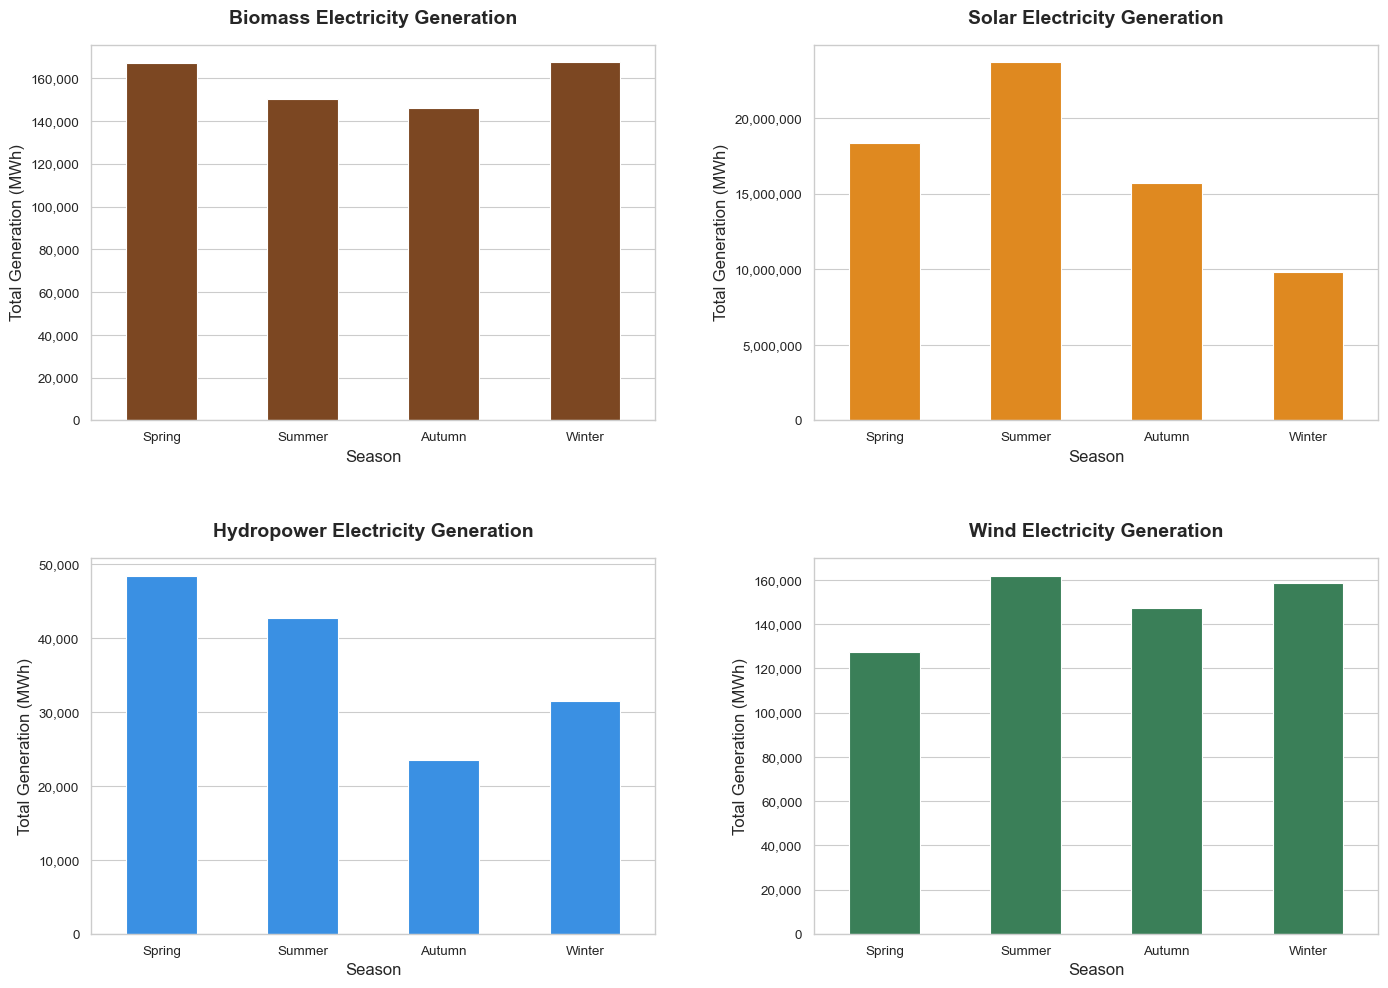

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. DOSYA YOLLARI VE VERİ OKUMA
# ==========================================
input_file = r"C:\Users\ismailgulsoy\dergi2\processed_data\steps\21_grafik_ceei.xlsx"
output_image = r"C:\Users\ismailgulsoy\dergi2\processed_data\steps\22_mevsimsel_uretim_ayri_grafikler.png"

df = pd.read_excel(input_file)

# ==========================================
# 2. VERİ ÖN İŞLEME VE MEVSİM ÇEVİRİSİ
# ==========================================
df['Season'] = df['Season'].replace({
    'İlkbahar': 'Spring',
    'Yaz': 'Summer',
    'Sonbahar': 'Autumn',
    'Kış': 'Winter'
})

# Mevsime göre üretim verilerinin toplamını alma
seasonal_data = df.groupby('Season')[['G_Biomass', 'G_Solar', 'G_Hydropower', 'G_Wind']].sum().reset_index()

# Mevsim sırasını İngilizce ve kronolojik formata sabitleme
mevsim_sirasi = ['Spring', 'Summer', 'Autumn', 'Winter']
seasonal_data['Season'] = pd.Categorical(seasonal_data['Season'], categories=mevsim_sirasi, ordered=True)
seasonal_data = seasonal_data.sort_values('Season')

# ==========================================
# 3. GRAFİK TASARIMI (2x2 GRID)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

kaynaklar = ['G_Biomass', 'G_Solar', 'G_Hydropower', 'G_Wind']
basliklar = ['Biomass Electricity Generation', 'Solar Electricity Generation', 'Hydropower Electricity Generation', 'Wind Electricity Generation']
renkler = ['#8B4513', '#FF8C00', '#1E90FF', '#2E8B57'] 

# Döngü ile 4 ayrı grafiğin çizdirilmesi
for i, (ax, kaynak, baslik, renk) in enumerate(zip(axes.flatten(), kaynaklar, basliklar, renkler)):
    sns.barplot(
        data=seasonal_data, 
        x='Season', 
        y=kaynak, 
        ax=ax, 
        color=renk,
        width=0.5  # Çubukları inceltmek için genişlik değeri eklendi (Varsayılan: 0.8)
    )
    
    # Başlık ile grafik arasına pad parametresi ile boşluk eklendi
    ax.set_title(baslik, fontsize=14, weight='bold', pad=15)
    ax.set_xlabel('Season', fontsize=12)
    ax.set_ylabel('Total Generation (MWh)', fontsize=12)
    
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f}".format(x)))

# ==========================================
# 4. KAYDETME VE GÖSTERİM
# ==========================================
# Grafikler arasındaki yatay (w_pad) ve dikey (h_pad) boşluklar artırıldı
plt.tight_layout(w_pad=4.0, h_pad=4.0)

plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Grafik başarıyla oluşturuldu ve kaydedildi:\n{output_image}")

plt.show()

C:\Users\ismailgulsoy\AppData\Local\Temp\ipykernel_3792\867590933.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
C:\Users\ismailgulsoy\AppData\Local\Temp\ipykernel_3792\867590933.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
C:\Users\ismailgulsoy\AppData\Local\Temp\ipykernel_3792\867590933.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
C:\Users\ismailgulsoy\AppData\Local\Temp\ipykernel_3792\867590933.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedL

Bölgesel grafik başarıyla oluşturuldu ve kaydedildi:
C:\Users\ismailgulsoy\dergi2\processed_data\steps\23_bolgesel_uretim_ayri_grafikler.png


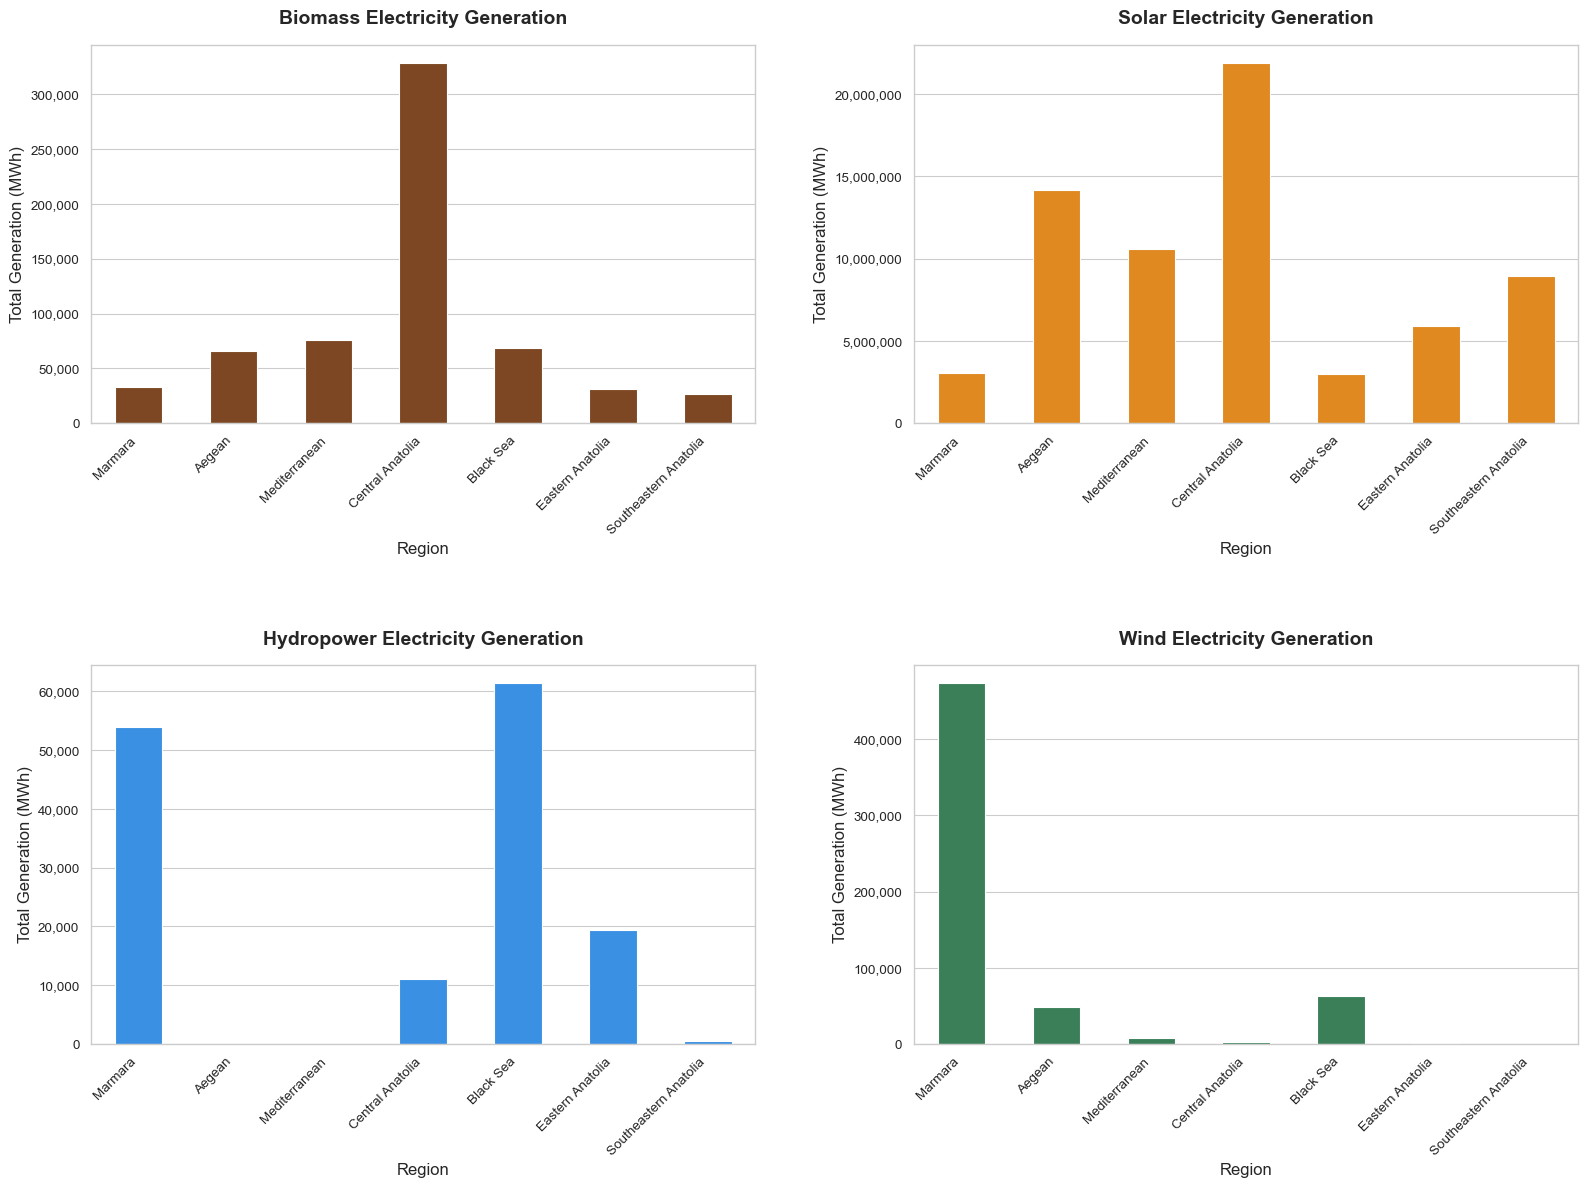

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. DOSYA YOLLARI VE VERİ OKUMA
# ==========================================
input_file = r"C:\Users\ismailgulsoy\dergi2\processed_data\steps\21_grafik_ceei.xlsx"
output_image = r"C:\Users\ismailgulsoy\dergi2\processed_data\steps\23_bolgesel_uretim_ayri_grafikler.png"

df = pd.read_excel(input_file)

# ==========================================
# 2. VERİ ÖN İŞLEME VE BÖLGE ÇEVİRİSİ
# ==========================================
# Veri setindeki Türkçe bölge isimlerini İngilizce akademik karşılıklarına çeviriyoruz.
bolge_ceviri = {
    'Marmara': 'Marmara',
    'Ege': 'Aegean',
    'Akdeniz': 'Mediterranean',
    'İç Anadolu': 'Central Anatolia',
    'Karadeniz': 'Black Sea',
    'Doğu Anadolu': 'Eastern Anatolia',
    'Güneydoğu Anadolu': 'Southeastern Anatolia'
}
df['Region'] = df['Region'].replace(bolge_ceviri)

# Bölgeye göre üretim verilerinin toplamını alma
regional_data = df.groupby('Region')[['G_Biomass', 'G_Solar', 'G_Hydropower', 'G_Wind']].sum().reset_index()

# Bölge sırasını İngilizce formata sabitleme
bolge_sirasi = ['Marmara', 'Aegean', 'Mediterranean', 'Central Anatolia', 'Black Sea', 'Eastern Anatolia', 'Southeastern Anatolia']
regional_data['Region'] = pd.Categorical(regional_data['Region'], categories=bolge_sirasi, ordered=True)
regional_data = regional_data.sort_values('Region')

# ==========================================
# 3. GRAFİK TASARIMI (2x2 GRID)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12)) # Etiketler sığsın diye figür boyutu hafif büyütüldü
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

kaynaklar = ['G_Biomass', 'G_Solar', 'G_Hydropower', 'G_Wind']
basliklar = ['Biomass Electricity Generation', 'Solar Electricity Generation', 'Hydropower Electricity Generation', 'Wind Electricity Generation']
renkler = ['#8B4513', '#FF8C00', '#1E90FF', '#2E8B57'] 

# Döngü ile 4 ayrı grafiğin çizdirilmesi
for i, (ax, kaynak, baslik, renk) in enumerate(zip(axes.flatten(), kaynaklar, basliklar, renkler)):
    sns.barplot(
        data=regional_data, 
        x='Region', 
        y=kaynak, 
        ax=ax, 
        color=renk,
        width=0.5  # Çubuk inceliği
    )
    
    # Başlık ve eksen ayarları
    ax.set_title(baslik, fontsize=14, weight='bold', pad=15)
    ax.set_xlabel('Region', fontsize=12)
    ax.set_ylabel('Total Generation (MWh)', fontsize=12)
    
    # Bölge isimleri uzun olduğu için X eksenindeki yazıları 45 derece yatırıyoruz
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    
    # Y eksenindeki rakamlara binlik ayırıcı ekleme
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f}".format(x)))

# ==========================================
# 4. KAYDETME VE GÖSTERİM
# ==========================================
# Grafikler arasındaki yatay ve dikey boşluklar
plt.tight_layout(w_pad=4.0, h_pad=5.0)

plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Bölgesel grafik başarıyla oluşturuldu ve kaydedildi:\n{output_image}")

plt.show()

Aktif iller bazlı grafikler kaydedildi: C:\Users\ismailgulsoy\dergi2\processed_data\steps\24_il_bazli_aktif_uretim_dagilimi.png


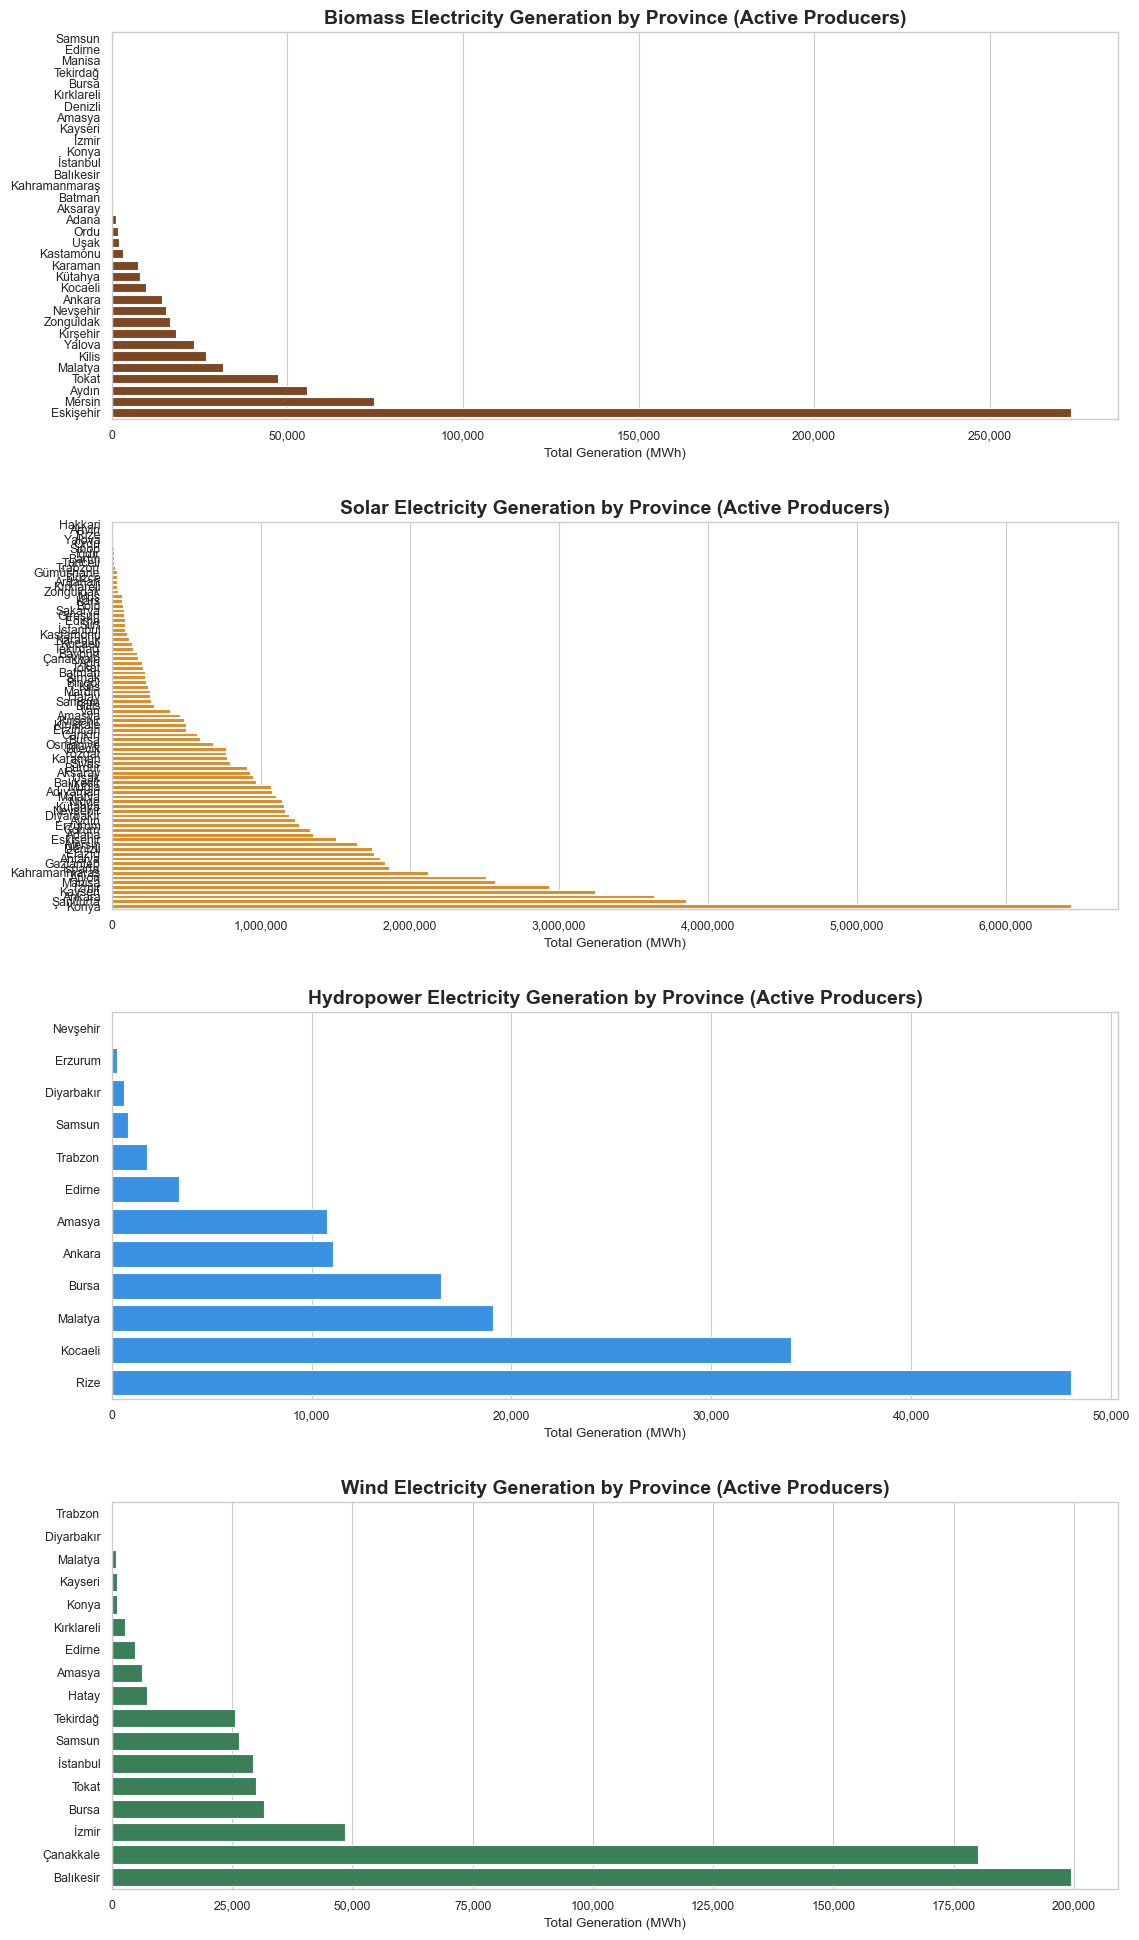

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dosya yollarının tanımlanması
input_file = r"C:\Users\ismailgulsoy\dergi2\processed_data\steps\21_grafik_ceei.xlsx"
output_image = r"C:\Users\ismailgulsoy\dergi2\processed_data\steps\24_il_bazli_aktif_uretim_dagilimi.png"

df = pd.read_excel(input_file)

# 2. İl isimleri sözlüğü (Daha önce tanımladığımız)
il_isimleri = {1: 'Adana', 2: 'Adıyaman', 3: 'Afyon', 4: 'Ağrı', 5: 'Amasya', 6: 'Ankara', 7: 'Antalya', 8: 'Artvin', 9: 'Aydın',
               10: 'Balıkesir', 11: 'Bilecik', 12: 'Bingöl', 13: 'Bitlis', 14: 'Bolu', 15: 'Burdur', 16: 'Bursa', 17: 'Çanakkale',
               18: 'Çankırı', 19: 'Çorum', 20: 'Denizli', 21: 'Diyarbakır', 22: 'Edirne', 23: 'Elazığ', 24: 'Erzincan', 25: 'Erzurum',
               26: 'Eskişehir', 27: 'Gaziantep', 28: 'Giresun', 29: 'Gümüşhane', 30: 'Hakkari', 31: 'Hatay', 32: 'Isparta', 33: 'Mersin',
               34: 'İstanbul', 35: 'İzmir', 36: 'Kars', 37: 'Kastamonu', 38: 'Kayseri', 39: 'Kırklareli', 40: 'Kırşehir', 41: 'Kocaeli',
               42: 'Konya', 43: 'Kütahya', 44: 'Malatya', 45: 'Manisa', 46: 'Kahramanmaraş', 47: 'Mardin', 48: 'Muğla', 49: 'Muş',
               50: 'Nevşehir', 51: 'Niğde', 52: 'Ordu', 53: 'Rize', 54: 'Sakarya', 55: 'Samsun', 56: 'Siirt', 57: 'Sinop', 58: 'Sivas',
               59: 'Tekirdağ', 60: 'Tokat', 61: 'Trabzon', 62: 'Tunceli', 63: 'Şanlıurfa', 64: 'Uşak', 65: 'Van', 66: 'Yozgat', 67: 'Zonguldak',
               68: 'Aksaray', 69: 'Bayburt', 70: 'Karaman', 71: 'Kırıkkale', 72: 'Batman', 73: 'Şırnak', 74: 'Bartın', 75: 'Ardahan',
               76: 'Iğdır', 77: 'Yalova', 78: 'Karabük', 79: 'Kilis', 80: 'Osmaniye', 81: 'Düzce'}
df['City'] = df['Plate'].map(il_isimleri)

# 3. Grafik Çizimi (Her kaynak için ayrı ayrı filtreleme)
kaynaklar = ['G_Biomass', 'G_Solar', 'G_Hydropower', 'G_Wind']
basliklar = ['Biomass', 'Solar', 'Hydropower', 'Wind']
renkler = ['#8B4513', '#FF8C00', '#1E90FF', '#2E8B57']

fig, axes = plt.subplots(4, 1, figsize=(12, 20)) # İhtiyaca göre boyut ayarlanabilir
sns.set_theme(style="whitegrid", context="paper")

for ax, kaynak, baslik, renk in zip(axes, kaynaklar, basliklar, renkler):
    # Sıfır olmayan verileri filtreleme
    active_data = df.groupby('City')[kaynak].sum().reset_index()
    active_data = active_data[active_data[kaynak] > 0]
    active_data = active_data.sort_values(by=kaynak, ascending=True)
    
    sns.barplot(data=active_data, y='City', x=kaynak, ax=ax, color=renk)
    ax.set_title(f'{baslik} Electricity Generation by Province (Active Producers)', fontsize=14, weight='bold')
    ax.set_ylabel('')
    ax.set_xlabel('Total Generation (MWh)')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f}".format(x)))

plt.tight_layout(pad=3.0)
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Aktif iller bazlı grafikler kaydedildi: {output_image}")
plt.show()

Top 10 il bazlı grafik kaydedildi: C:\Users\ismailgulsoy\dergi2\processed_data\steps\24_il_bazli_top10_uretim.png


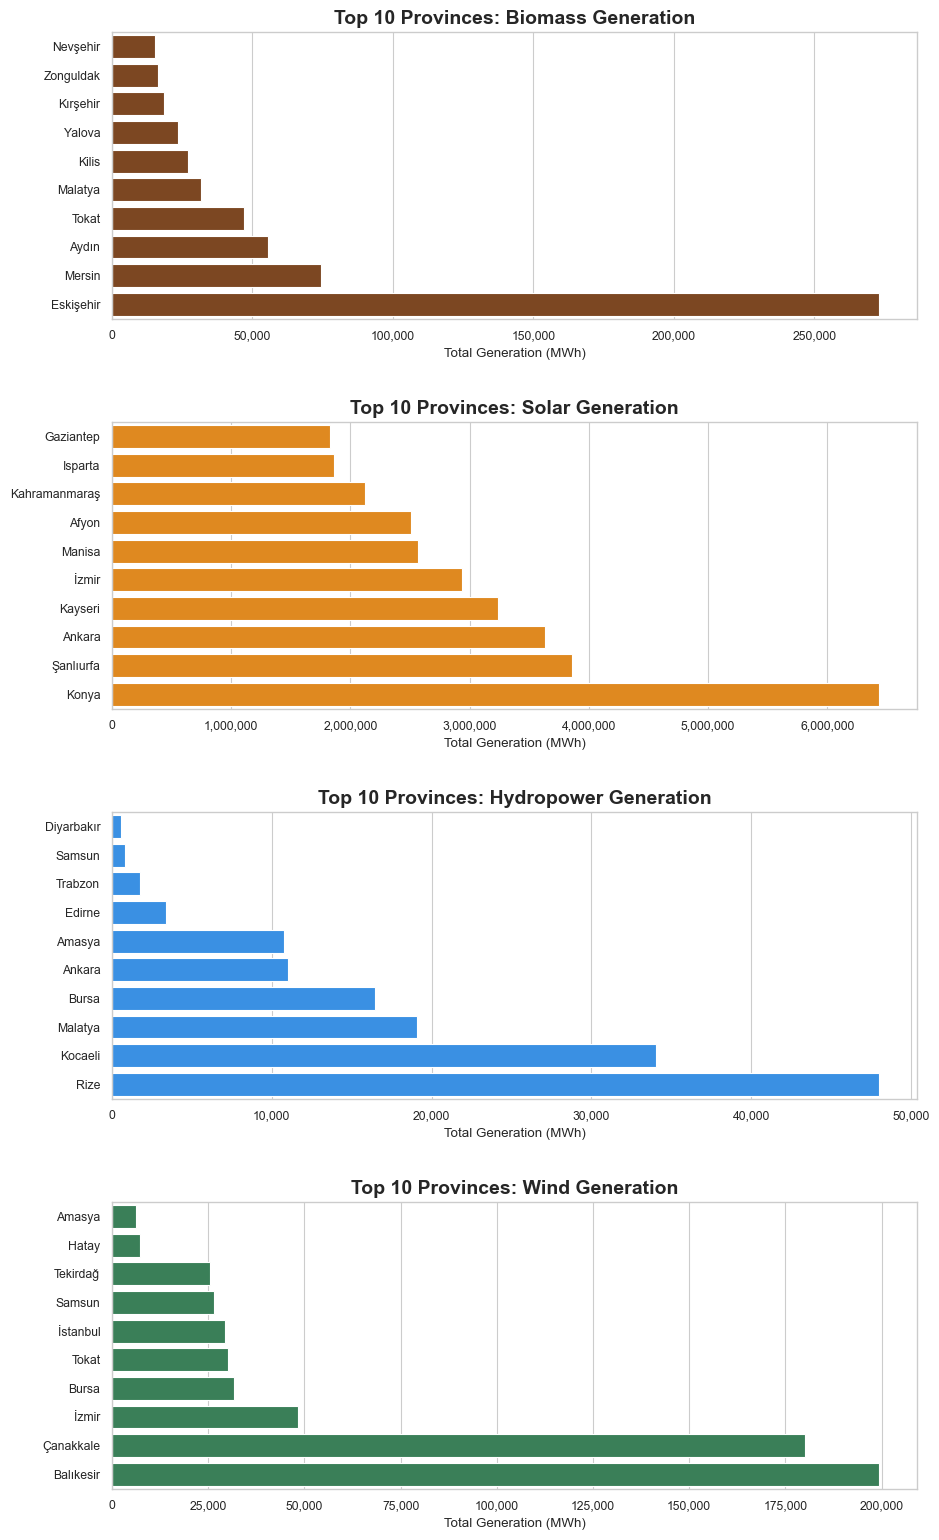

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dosya yollarının tanımlanması
input_file = r"C:\Users\ismailgulsoy\dergi2\processed_data\steps\21_grafik_ceei.xlsx"
output_image = r"C:\Users\ismailgulsoy\dergi2\processed_data\steps\24_il_bazli_top10_uretim.png"

df = pd.read_excel(input_file)

# 2. İl isimleri sözlüğü
il_isimleri = {1: 'Adana', 2: 'Adıyaman', 3: 'Afyon', 4: 'Ağrı', 5: 'Amasya', 6: 'Ankara', 7: 'Antalya', 8: 'Artvin', 9: 'Aydın',
               10: 'Balıkesir', 11: 'Bilecik', 12: 'Bingöl', 13: 'Bitlis', 14: 'Bolu', 15: 'Burdur', 16: 'Bursa', 17: 'Çanakkale',
               18: 'Çankırı', 19: 'Çorum', 20: 'Denizli', 21: 'Diyarbakır', 22: 'Edirne', 23: 'Elazığ', 24: 'Erzincan', 25: 'Erzurum',
               26: 'Eskişehir', 27: 'Gaziantep', 28: 'Giresun', 29: 'Gümüşhane', 30: 'Hakkari', 31: 'Hatay', 32: 'Isparta', 33: 'Mersin',
               34: 'İstanbul', 35: 'İzmir', 36: 'Kars', 37: 'Kastamonu', 38: 'Kayseri', 39: 'Kırklareli', 40: 'Kırşehir', 41: 'Kocaeli',
               42: 'Konya', 43: 'Kütahya', 44: 'Malatya', 45: 'Manisa', 46: 'Kahramanmaraş', 47: 'Mardin', 48: 'Muğla', 49: 'Muş',
               50: 'Nevşehir', 51: 'Niğde', 52: 'Ordu', 53: 'Rize', 54: 'Sakarya', 55: 'Samsun', 56: 'Siirt', 57: 'Sinop', 58: 'Sivas',
               59: 'Tekirdağ', 60: 'Tokat', 61: 'Trabzon', 62: 'Tunceli', 63: 'Şanlıurfa', 64: 'Uşak', 65: 'Van', 66: 'Yozgat', 67: 'Zonguldak',
               68: 'Aksaray', 69: 'Bayburt', 70: 'Karaman', 71: 'Kırıkkale', 72: 'Batman', 73: 'Şırnak', 74: 'Bartın', 75: 'Ardahan',
               76: 'Iğdır', 77: 'Yalova', 78: 'Karabük', 79: 'Kilis', 80: 'Osmaniye', 81: 'Düzce'}
df['City'] = df['Plate'].map(il_isimleri)

# 3. Grafik Çizimi (Top 10 Filtresi)
kaynaklar = ['G_Biomass', 'G_Solar', 'G_Hydropower', 'G_Wind']
basliklar = ['Biomass', 'Solar', 'Hydropower', 'Wind']
renkler = ['#8B4513', '#FF8C00', '#1E90FF', '#2E8B57']

fig, axes = plt.subplots(4, 1, figsize=(10, 16))
sns.set_theme(style="whitegrid", context="paper")

for ax, kaynak, baslik, renk in zip(axes, kaynaklar, basliklar, renkler):
    # Sıfır olmayanları filtrele ve Top 10'u seç
    top10_data = df.groupby('City')[kaynak].sum().reset_index()
    top10_data = top10_data[top10_data[kaynak] > 0].sort_values(by=kaynak, ascending=False).head(10)
    
    # Sıralamayı grafik için tersine çeviriyoruz (En büyük üstte görünsün diye)
    sns.barplot(data=top10_data.sort_values(by=kaynak, ascending=True), y='City', x=kaynak, ax=ax, color=renk)
    
    ax.set_title(f'Top 10 Provinces: {baslik} Generation', fontsize=14, weight='bold')
    ax.set_ylabel('')
    ax.set_xlabel('Total Generation (MWh)')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f}".format(x)))

plt.tight_layout(pad=3.0)
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Top 10 il bazlı grafik kaydedildi: {output_image}")
plt.show()

Grafik kaydedildi: C:\Users\ismailgulsoy\dergi2\processed_data\steps\24_il_bazli_top10_uretim_yan_yana.png


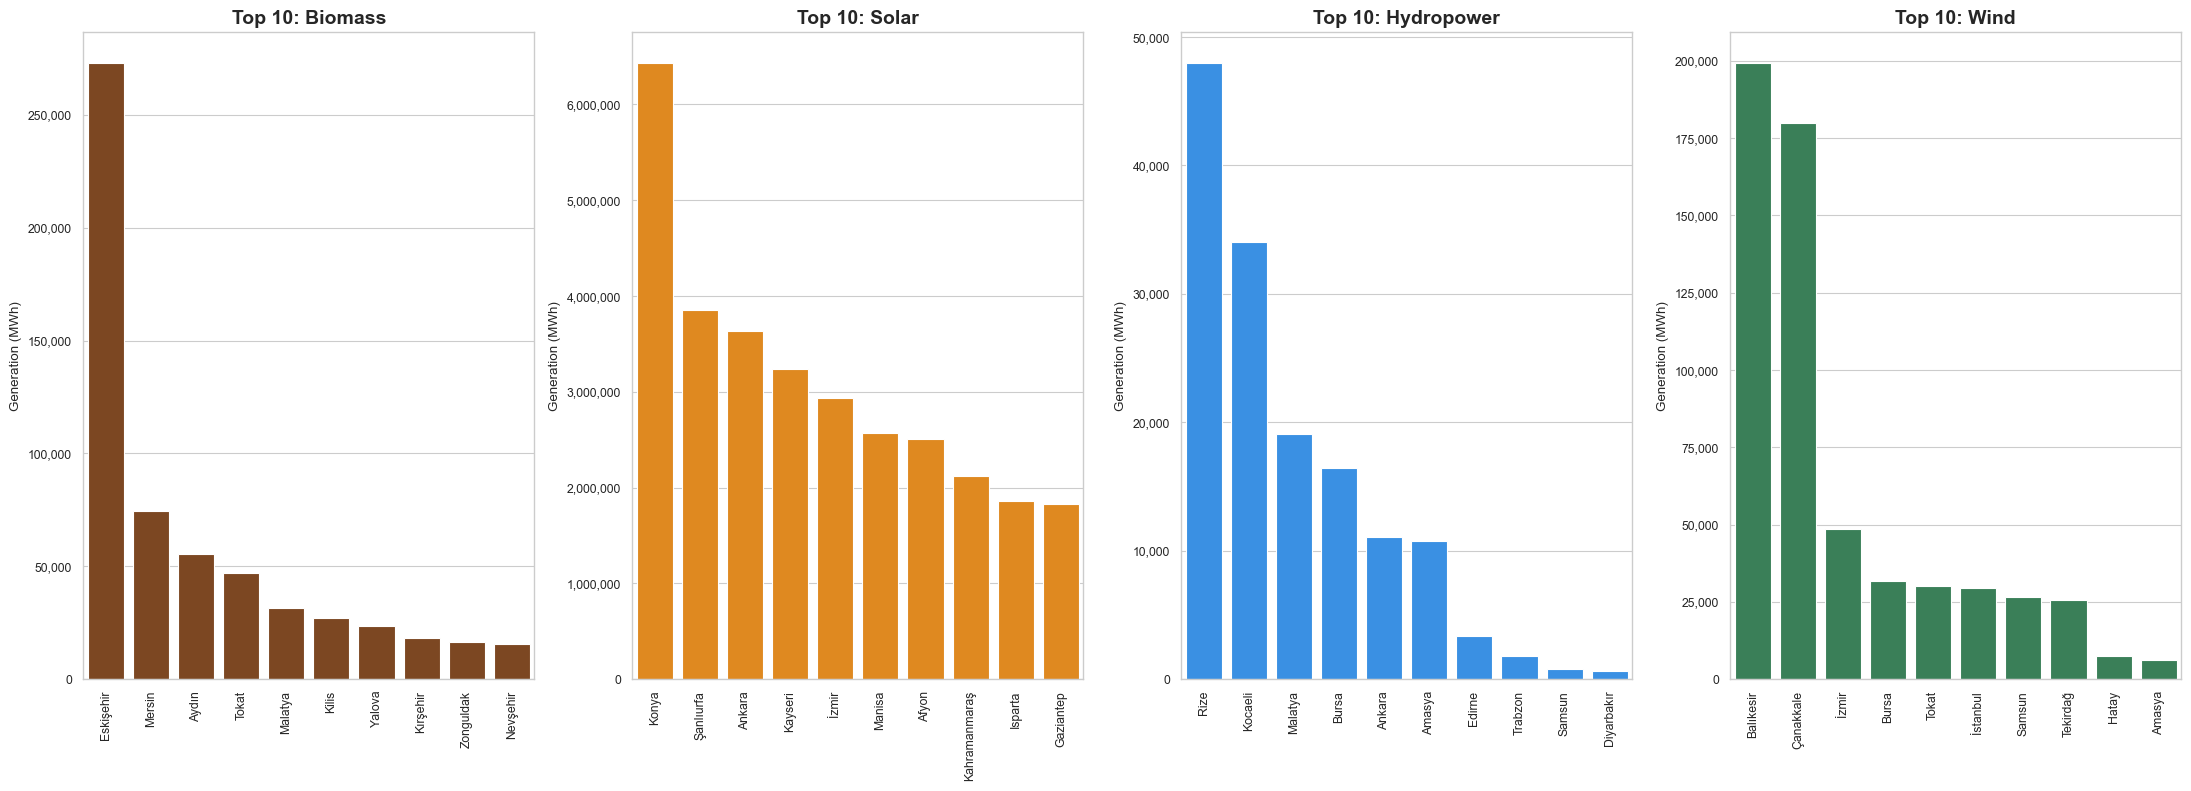

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dosya yollarının tanımlanması
input_file = r"C:\Users\ismailgulsoy\dergi2\processed_data\steps\21_grafik_ceei.xlsx"
output_image = r"C:\Users\ismailgulsoy\dergi2\processed_data\steps\24_il_bazli_top10_uretim_yan_yana.png"

df = pd.read_excel(input_file)

# 2. İl isimleri sözlüğü
il_isimleri = {1: 'Adana', 2: 'Adıyaman', 3: 'Afyon', 4: 'Ağrı', 5: 'Amasya', 6: 'Ankara', 7: 'Antalya', 8: 'Artvin', 9: 'Aydın',
               10: 'Balıkesir', 11: 'Bilecik', 12: 'Bingöl', 13: 'Bitlis', 14: 'Bolu', 15: 'Burdur', 16: 'Bursa', 17: 'Çanakkale',
               18: 'Çankırı', 19: 'Çorum', 20: 'Denizli', 21: 'Diyarbakır', 22: 'Edirne', 23: 'Elazığ', 24: 'Erzincan', 25: 'Erzurum',
               26: 'Eskişehir', 27: 'Gaziantep', 28: 'Giresun', 29: 'Gümüşhane', 30: 'Hakkari', 31: 'Hatay', 32: 'Isparta', 33: 'Mersin',
               34: 'İstanbul', 35: 'İzmir', 36: 'Kars', 37: 'Kastamonu', 38: 'Kayseri', 39: 'Kırklareli', 40: 'Kırşehir', 41: 'Kocaeli',
               42: 'Konya', 43: 'Kütahya', 44: 'Malatya', 45: 'Manisa', 46: 'Kahramanmaraş', 47: 'Mardin', 48: 'Muğla', 49: 'Muş',
               50: 'Nevşehir', 51: 'Niğde', 52: 'Ordu', 53: 'Rize', 54: 'Sakarya', 55: 'Samsun', 56: 'Siirt', 57: 'Sinop', 58: 'Sivas',
               59: 'Tekirdağ', 60: 'Tokat', 61: 'Trabzon', 62: 'Tunceli', 63: 'Şanlıurfa', 64: 'Uşak', 65: 'Van', 66: 'Yozgat', 67: 'Zonguldak',
               68: 'Aksaray', 69: 'Bayburt', 70: 'Karaman', 71: 'Kırıkkale', 72: 'Batman', 73: 'Şırnak', 74: 'Bartın', 75: 'Ardahan',
               76: 'Iğdır', 77: 'Yalova', 78: 'Karabük', 79: 'Kilis', 80: 'Osmaniye', 81: 'Düzce'}
df['City'] = df['Plate'].map(il_isimleri)

# 3. Grafik Çizimi (1 satır, 4 sütun)
kaynaklar = ['G_Biomass', 'G_Solar', 'G_Hydropower', 'G_Wind']
basliklar = ['Biomass', 'Solar', 'Hydropower', 'Wind']
renkler = ['#8B4513', '#FF8C00', '#1E90FF', '#2E8B57']

# Yan yana grafik için 1x4 düzeni
fig, axes = plt.subplots(1, 4, figsize=(22, 8)) 
sns.set_theme(style="whitegrid", context="paper")

for ax, kaynak, baslik, renk in zip(axes, kaynaklar, basliklar, renkler):
    # Sıfır olmayanları filtrele ve Top 10'u seç
    top10_data = df.groupby('City')[kaynak].sum().reset_index()
    top10_data = top10_data[top10_data[kaynak] > 0].sort_values(by=kaynak, ascending=False).head(10)
    
    # X ekseninde iller olacak şekilde (vertical bar)
    sns.barplot(data=top10_data, x='City', y=kaynak, ax=ax, color=renk)
    
    ax.set_title(f'Top 10: {baslik}', fontsize=14, weight='bold')
    ax.set_xlabel('') # X ekseni etiketi zaten il isimleri olduğu için boş bırakıldı
    ax.set_ylabel('Generation (MWh)')
    
    # İl isimlerini 90 derece döndür
    ax.tick_params(axis='x', rotation=90)
    
    # Y eksenini formatla
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f}".format(x)))

plt.tight_layout()
plt.savefig(output_image, dpi=300, bbox_inches='tight')
print(f"Grafik kaydedildi: {output_image}")
plt.show()

In [18]:
import pandas as pd

# 1. Veri okuma
input_file = r"C:\Users\ismailgulsoy\dergi2\processed_data\steps\21_grafik_ceei.xlsx"
df = pd.read_excel(input_file)

# 2. İllere göre toplam üretimleri grupla
city_summary = df.groupby('Plate')[['G_Biomass', 'G_Solar', 'G_Hydropower', 'G_Wind']].sum()

# 3. Her kaynak için 0'dan büyük olanları 1, olmayanları 0 yap (Boolean maske)
diversity_mask = (city_summary > 0).astype(int)

# 4. Satır toplamını al (Bu, ilin kaç farklı kaynağa sahip olduğunu verir)
city_summary['Diversity_Count'] = diversity_mask.sum(axis=1)

# 5. Gruplandır
diversity_groups = city_summary.groupby('Diversity_Count').size().reset_index(name='Province_Count')

# Sonuçları ekrana yazdır
print("Enerji Kaynağı Çeşitliliğine Göre İller:")
print(diversity_groups)

# İstersen bu grupları bir Excel'e kaydedelim
output_diversity = r"C:\Users\ismailgulsoy\dergi2\processed_data\steps\25_enerji_cesitliligi.xlsx"
city_summary.to_excel(output_diversity)

Enerji Kaynağı Çeşitliliğine Göre İller:
   Diversity_Count  Province_Count
0                1              41
1                2              22
2                3              13
3                4               5


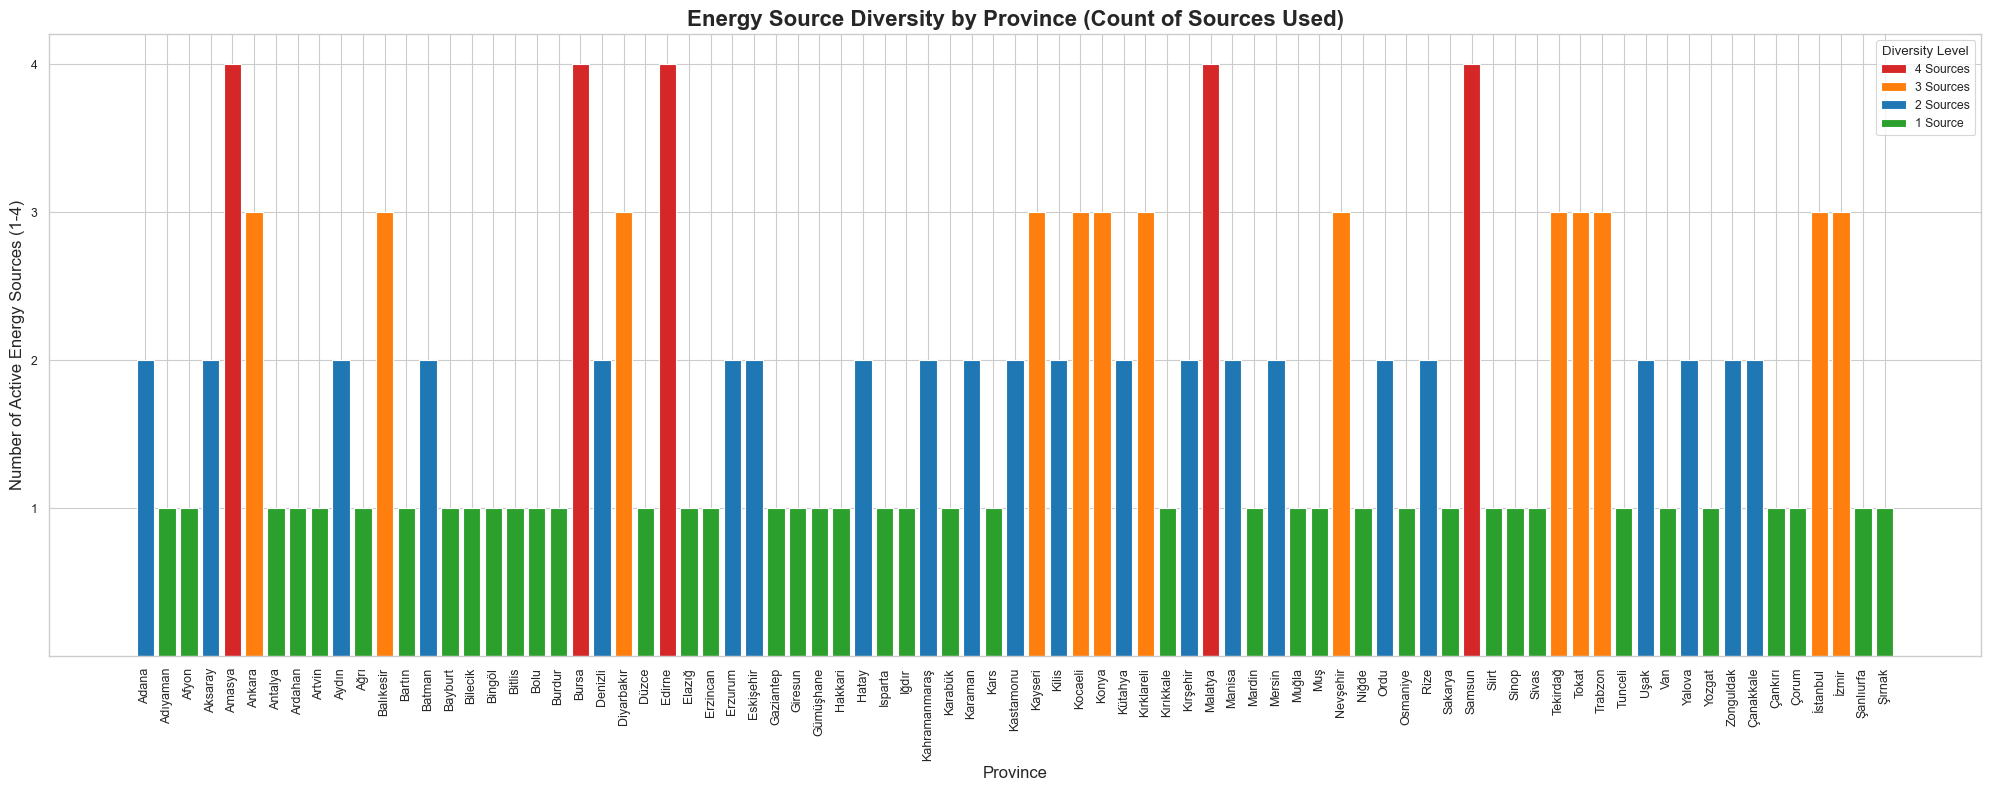

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Veri Okuma
input_file = r"C:\Users\ismailgulsoy\dergi2\processed_data\steps\21_grafik_ceei.xlsx"
df = pd.read_excel(input_file)

# 2. İlleri eşleştirme (Daha önce tanımlanan il_isimleri sözlüğünü kullanıyoruz)
il_isimleri = {1: 'Adana', 2: 'Adıyaman', 3: 'Afyon', 4: 'Ağrı', 5: 'Amasya', 6: 'Ankara', 7: 'Antalya', 8: 'Artvin', 9: 'Aydın',
               10: 'Balıkesir', 11: 'Bilecik', 12: 'Bingöl', 13: 'Bitlis', 14: 'Bolu', 15: 'Burdur', 16: 'Bursa', 17: 'Çanakkale',
               18: 'Çankırı', 19: 'Çorum', 20: 'Denizli', 21: 'Diyarbakır', 22: 'Edirne', 23: 'Elazığ', 24: 'Erzincan', 25: 'Erzurum',
               26: 'Eskişehir', 27: 'Gaziantep', 28: 'Giresun', 29: 'Gümüşhane', 30: 'Hakkari', 31: 'Hatay', 32: 'Isparta', 33: 'Mersin',
               34: 'İstanbul', 35: 'İzmir', 36: 'Kars', 37: 'Kastamonu', 38: 'Kayseri', 39: 'Kırklareli', 40: 'Kırşehir', 41: 'Kocaeli',
               42: 'Konya', 43: 'Kütahya', 44: 'Malatya', 45: 'Manisa', 46: 'Kahramanmaraş', 47: 'Mardin', 48: 'Muğla', 49: 'Muş',
               50: 'Nevşehir', 51: 'Niğde', 52: 'Ordu', 53: 'Rize', 54: 'Sakarya', 55: 'Samsun', 56: 'Siirt', 57: 'Sinop', 58: 'Sivas',
               59: 'Tekirdağ', 60: 'Tokat', 61: 'Trabzon', 62: 'Tunceli', 63: 'Şanlıurfa', 64: 'Uşak', 65: 'Van', 66: 'Yozgat', 67: 'Zonguldak',
               68: 'Aksaray', 69: 'Bayburt', 70: 'Karaman', 71: 'Kırıkkale', 72: 'Batman', 73: 'Şırnak', 74: 'Bartın', 75: 'Ardahan',
               76: 'Iğdır', 77: 'Yalova', 78: 'Karabük', 79: 'Kilis', 80: 'Osmaniye', 81: 'Düzce'}
df['City'] = df['Plate'].map(il_isimleri)

# 3. Çeşitlilik Hesaplama
city_summary = df.groupby('City')[['G_Biomass', 'G_Solar', 'G_Hydropower', 'G_Wind']].sum()
diversity_count = (city_summary > 0).astype(int).sum(axis=1).reset_index(name='Count')

# 4. Renk Haritası
color_map = {4: '#d62728', 3: '#ff7f0e', 2: '#1f77b4', 1: '#2ca02c'}
diversity_count['Color'] = diversity_count['Count'].map(color_map)

# 5. Görselleştirme
plt.figure(figsize=(20, 8))
plt.bar(diversity_count['City'], diversity_count['Count'], color=diversity_count['Color'])

plt.title('Energy Source Diversity by Province (Count of Sources Used)', fontsize=16, weight='bold')
plt.xlabel('Province', fontsize=12)
plt.ylabel('Number of Active Energy Sources (1-4)', fontsize=12)
plt.xticks(rotation=90, fontsize=9)
plt.yticks([1, 2, 3, 4])

# Lejant ekleme
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#d62728', label='4 Sources'),
                   Patch(facecolor='#ff7f0e', label='3 Sources'),
                   Patch(facecolor='#1f77b4', label='2 Sources'),
                   Patch(facecolor='#2ca02c', label='1 Source')]
plt.legend(handles=legend_elements, title="Diversity Level")

plt.tight_layout()
plt.savefig(r"C:\Users\ismailgulsoy\dergi2\processed_data\steps\25_enerji_cesitliligi_grafik.png", dpi=300)
plt.show()

In [20]:
# Hangi ilin kaç farklı kaynağa sahip olduğunu yazdır
print("İl Enerji Kaynağı Sayısı Dağılımı:")
print(diversity_count[['City', 'Count']].sort_values(by='Count', ascending=False))

# Toplam il sayısını kontrol et
print(f"\nToplam il sayısı: {len(diversity_count)}")

İl Enerji Kaynağı Sayısı Dağılımı:
       City  Count
49  Malatya      4
20    Bursa      4
4    Amasya      4
24   Edirne      4
61   Samsun      4
..      ...    ...
53    Muğla      1
54      Muş      1
17   Bitlis      1
56    Niğde      1
80   Şırnak      1

[81 rows x 2 columns]

Toplam il sayısı: 81


In [21]:
import pandas as pd

# Veriyi oku
file_path = r"C:\Users\ismailgulsoy\dergi2\processed_data\steps\21_grafik_ceei.xlsx"
df = pd.read_excel(file_path)

# Her ilin 4 kaynak için toplam üretimlerini grupla
city_summary = df.groupby('Plate')[['G_Biomass', 'G_Solar', 'G_Hydropower', 'G_Wind']].sum()

# 0'dan büyük olanları 1, olmayanları 0 yap
active_status = (city_summary > 0).astype(int)

# İlin sahip olduğu aktif kaynak sayısını hesapla
active_status['Source_Count'] = active_status.sum(axis=1)

# Sonuç: Her ilin kaç farklı kaynağa sahip olduğunun dağılımı
print(active_status['Source_Count'].value_counts())

# Sadece 1 kaynaklı iller (Eğer varsa)
print("\nSadece 1 enerji kaynağına sahip iller:")
print(active_status[active_status['Source_Count'] == 1].index.tolist())

Source_Count
1    41
2    22
3    13
4     5
Name: count, dtype: int64

Sadece 1 enerji kaynağına sahip iller:
[2, 3, 4, 7, 8, 11, 12, 13, 14, 15, 18, 19, 23, 24, 27, 28, 29, 30, 32, 36, 47, 48, 49, 51, 54, 56, 57, 58, 62, 63, 65, 66, 69, 71, 73, 74, 75, 76, 78, 80, 81]


In [22]:
import pandas as pd

# Veriyi oku
file_path = r"C:\Users\ismailgulsoy\dergi2\processed_data\steps\21_grafik_ceei.xlsx"
df = pd.read_excel(file_path)

# Her il için 4 kaynakta toplam üretim
city_summary = df.groupby('Plate')[['G_Biomass', 'G_Solar', 'G_Hydropower', 'G_Wind']].sum()

# Hiçbir kaynakta üretimi olmayan illeri bul (toplam üretim 0 olanlar)
zero_production_provinces = city_summary[city_summary.sum(axis=1) == 0].index.tolist()

print("Hiçbir enerji kaynağında üretimi olmayan illerin plaka kodları:")
print(zero_production_provinces)

Hiçbir enerji kaynağında üretimi olmayan illerin plaka kodları:
[]


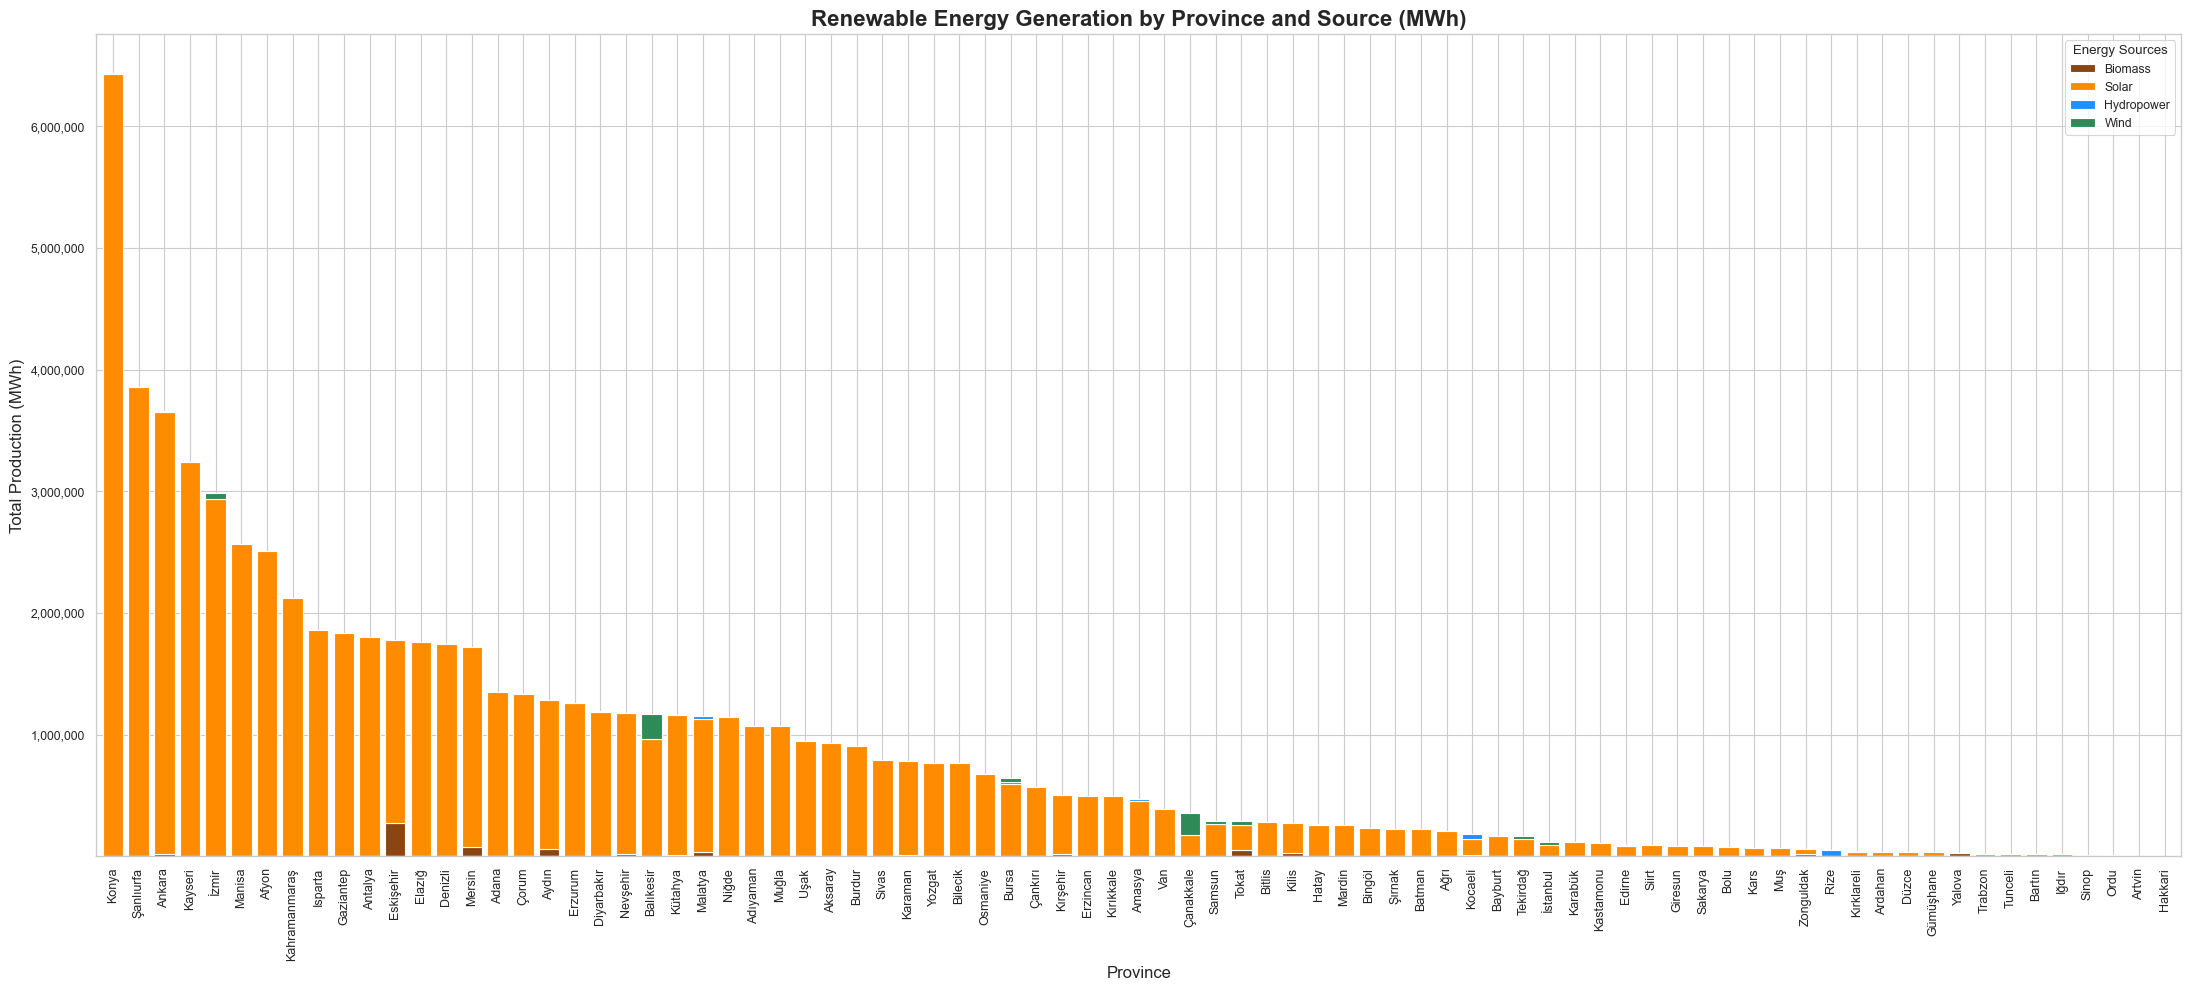

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Veri Okuma
input_file = r"C:\Users\ismailgulsoy\dergi2\processed_data\steps\21_grafik_ceei.xlsx"
df = pd.read_excel(input_file)

# 2. İsim eşleştirme sözlüğü (daha önce kullandığımız)
il_isimleri = {1: 'Adana', 2: 'Adıyaman', 3: 'Afyon', 4: 'Ağrı', 5: 'Amasya', 6: 'Ankara', 7: 'Antalya', 8: 'Artvin', 9: 'Aydın',
               10: 'Balıkesir', 11: 'Bilecik', 12: 'Bingöl', 13: 'Bitlis', 14: 'Bolu', 15: 'Burdur', 16: 'Bursa', 17: 'Çanakkale',
               18: 'Çankırı', 19: 'Çorum', 20: 'Denizli', 21: 'Diyarbakır', 22: 'Edirne', 23: 'Elazığ', 24: 'Erzincan', 25: 'Erzurum',
               26: 'Eskişehir', 27: 'Gaziantep', 28: 'Giresun', 29: 'Gümüşhane', 30: 'Hakkari', 31: 'Hatay', 32: 'Isparta', 33: 'Mersin',
               34: 'İstanbul', 35: 'İzmir', 36: 'Kars', 37: 'Kastamonu', 38: 'Kayseri', 39: 'Kırklareli', 40: 'Kırşehir', 41: 'Kocaeli',
               42: 'Konya', 43: 'Kütahya', 44: 'Malatya', 45: 'Manisa', 46: 'Kahramanmaraş', 47: 'Mardin', 48: 'Muğla', 49: 'Muş',
               50: 'Nevşehir', 51: 'Niğde', 52: 'Ordu', 53: 'Rize', 54: 'Sakarya', 55: 'Samsun', 56: 'Siirt', 57: 'Sinop', 58: 'Sivas',
               59: 'Tekirdağ', 60: 'Tokat', 61: 'Trabzon', 62: 'Tunceli', 63: 'Şanlıurfa', 64: 'Uşak', 65: 'Van', 66: 'Yozgat', 67: 'Zonguldak',
               68: 'Aksaray', 69: 'Bayburt', 70: 'Karaman', 71: 'Kırıkkale', 72: 'Batman', 73: 'Şırnak', 74: 'Bartın', 75: 'Ardahan',
               76: 'Iğdır', 77: 'Yalova', 78: 'Karabük', 79: 'Kilis', 80: 'Osmaniye', 81: 'Düzce'}
df['City'] = df['Plate'].map(il_isimleri)

# 3. İllere göre toplam üretim (Gruplama)
city_summary = df.groupby('City')[['G_Biomass', 'G_Solar', 'G_Hydropower', 'G_Wind']].sum()

# İlleri toplam üretim miktarına göre sıralayalım (böylece grafik daha okunaklı olur)
city_summary['Total'] = city_summary.sum(axis=1)
city_summary = city_summary.sort_values(by='Total', ascending=False).drop(columns=['Total'])

# 4. Yığılmış (Stacked) Çubuk Grafiği
ax = city_summary.plot(kind='bar', stacked=True, figsize=(22, 10), 
                       color=['#8B4513', '#FF8C00', '#1E90FF', '#2E8B57'], width=0.8)

plt.title('Renewable Energy Generation by Province and Source (MWh)', fontsize=16, weight='bold')
plt.xlabel('Province', fontsize=12)
plt.ylabel('Total Production (MWh)', fontsize=12)
plt.xticks(rotation=90, fontsize=9)

# Y eksenini formatla (binlik ayırıcı)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f}".format(x)))

# Lejantı düzenle
plt.legend(['Biomass', 'Solar', 'Hydropower', 'Wind'], title="Energy Sources")

plt.tight_layout()
plt.savefig(r"C:\Users\ismailgulsoy\dergi2\processed_data\steps\25_enerji_uretim_yigilmali.png", dpi=300)
plt.show()

In [27]:
import pandas as pd

# 1. Veri Okuma
input_file = r"C:\Users\ismailgulsoy\dergi2\processed_data\steps\21_grafik_ceei.xlsx"
df = pd.read_excel(input_file)

# 2. İl isimleri sözlüğü
il_isimleri = {1: 'Adana', 2: 'Adıyaman', 3: 'Afyon', 4: 'Ağrı', 5: 'Amasya', 6: 'Ankara', 7: 'Antalya', 8: 'Artvin', 9: 'Aydın',
               10: 'Balıkesir', 11: 'Bilecik', 12: 'Bingöl', 13: 'Bitlis', 14: 'Bolu', 15: 'Burdur', 16: 'Bursa', 17: 'Çanakkale',
               18: 'Çankırı', 19: 'Çorum', 20: 'Denizli', 21: 'Diyarbakır', 22: 'Edirne', 23: 'Elazığ', 24: 'Erzincan', 25: 'Erzurum',
               26: 'Eskişehir', 27: 'Gaziantep', 28: 'Giresun', 29: 'Gümüşhane', 30: 'Hakkari', 31: 'Hatay', 32: 'Isparta', 33: 'Mersin',
               34: 'İstanbul', 35: 'İzmir', 36: 'Kars', 37: 'Kastamonu', 38: 'Kayseri', 39: 'Kırklareli', 40: 'Kırşehir', 41: 'Kocaeli',
               42: 'Konya', 43: 'Kütahya', 44: 'Malatya', 45: 'Manisa', 46: 'Kahramanmaraş', 47: 'Mardin', 48: 'Muğla', 49: 'Muş',
               50: 'Nevşehir', 51: 'Niğde', 52: 'Ordu', 53: 'Rize', 54: 'Sakarya', 55: 'Samsun', 56: 'Siirt', 57: 'Sinop', 58: 'Sivas',
               59: 'Tekirdağ', 60: 'Tokat', 61: 'Trabzon', 62: 'Tunceli', 63: 'Şanlıurfa', 64: 'Uşak', 65: 'Van', 66: 'Yozgat', 67: 'Zonguldak',
               68: 'Aksaray', 69: 'Bayburt', 70: 'Karaman', 71: 'Kırıkkale', 72: 'Batman', 73: 'Şırnak', 74: 'Bartın', 75: 'Ardahan',
               76: 'Iğdır', 77: 'Yalova', 78: 'Karabük', 79: 'Kilis', 80: 'Osmaniye', 81: 'Düzce'}
df['City'] = df['Plate'].map(il_isimleri)

# 3. İllere göre toplam üretim (Gruplama)
# Tabloda temiz görünmesi için sütun isimlerini İngilizce akademik isimlerle değiştirelim
summary_table = df.groupby('City')[['G_Biomass', 'G_Solar', 'G_Hydropower', 'G_Wind']].sum()
summary_table.columns = ['Biomass (MWh)', 'Solar (MWh)', 'Hydropower (MWh)', 'Wind (MWh)']

# Toplam sütunu ekleyelim
summary_table['Total Production (MWh)'] = summary_table.sum(axis=1)

# En yüksek üretim yapan illeri en başa alalım
summary_table = summary_table.sort_values(by='Total Production (MWh)', ascending=False)

# 4. Tabloyu Excel olarak kaydet
output_path = r"C:\Users\ismailgulsoy\dergi2\processed_data\steps\26_iller_bazli_uretim_tablosu.xlsx"
summary_table.to_excel(output_path)

print(f"Tablo başarıyla oluşturuldu ve kaydedildi: {output_path}")
print("\nTablonun ilk 5 satırı:")
print(summary_table.head())

Tablo başarıyla oluşturuldu ve kaydedildi: C:\Users\ismailgulsoy\dergi2\processed_data\steps\26_iller_bazli_uretim_tablosu.xlsx

Tablonun ilk 5 satırı:
           Biomass (MWh)  Solar (MWh)  Hydropower (MWh)  Wind (MWh)  \
City                                                                  
Konya            14.1101   6432477.82              0.00     1119.15   
Şanlıurfa         0.0000   3855089.55              0.00        0.00   
Ankara        14278.8800   3635599.37          11047.72        0.00   
Kayseri           4.1002   3242169.61              0.00      977.92   
İzmir             5.0000   2933858.90              0.00    48472.77   

           Total Production (MWh)  
City                               
Konya                6.433611e+06  
Şanlıurfa            3.855090e+06  
Ankara               3.660926e+06  
Kayseri              3.243152e+06  
İzmir                2.982337e+06  
